**Comparative Study of Machine Learning Models for Handwritten Digit Classification**

**Student Name:** Kate  
**Course:** Data Science    
**Module:** Machine Learning  

# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b>SVM-DT-RF Project (Hand Written Digits)</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to know about the updates, please don't forget to follow us. </b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [WhatsApp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [LinkedIn](https://www.linkedin.com/company/techproeducation/mycompany/) |

# WELCOME!

**Data reference link :**

https://journals.tubitak.gov.tr/cgi/viewcontent.cgi?article=3717&context=elektrik

https://archive.ics.uci.edu/dataset/81/pen+based+recognition+of+handwritten+digits

- This is a dataset used to recognize handwritten digits.

- The dataset contains scanned images of handwritten digits.

- The dataset has a total of 10 classes, with each class representing a digit between 0 and 9.

- Data from 44 subjects, with 250 samples each, has been collected.

- The dataset includes information about which digit each image represents, in addition to the image data.

- This dataset is often used to evaluate the performance of machine learning algorithms in handwriting recognition.

- It is also a popular dataset used in the training of deep learning models.

**Pen-Based Recognition of Handwritten Digits**

- We are creating a digit database by collecting 250 samples from a total of 44 writers. Samples written by 30 writers are used for training, cross-validation, and author-dependent testing, while samples from the remaining 14 writers are used for author-independent testing. This database is also available in UNIPEN format.

- We use a WACOM PL-100V pressure-sensitive tablet with an integrated LCD screen and a wireless pen. The input and display areas are located in the same place. This tablet, connected to the serial port of an Intel 486-based computer, allows us to collect handwriting samples. The tablet sends $x$ and $y$ tablet coordinates and pen pressure level values at fixed time intervals of 100 milliseconds (sampling rate).

- These writers are asked to write 250 digits in random order in boxes with a resolution of 500 by 500 tablet pixels. The subject is only monitored during the first input screens. Each screen contains five boxes displaying the digits to be written. Subjects are instructed to write only within these boxes. If they make a mistake or are unsatisfied with their writing, they are instructed to clear the contents of a box using a button on the screen. Since most writers are unfamiliar with such input devices, the first ten digits are ignored, although subjects are unaware of this.

- In our study, we only use ($x, y$) coordinate data. Pen pressure level values are ignored. First, we apply normalization to make our representation invariant to translations and scale distortions. The raw data from the tablet consists of integer values between 0 and 500 (tablet input box resolution). The new coordinates are adjusted so that the coordinate with the maximum range varies between 0 and 100. Since most characters are taller than they are wide, $x$ generally remains within this range.

**Breakdown of values**
The **Pen-Digit Dataset** is a collection of data that shows how people write numbers (0 to 9) using a special tablet that can track the pen's movements.

- When someone writes a number on this tablet, the **X** and **Y** values show where the pen is on the tablet.
- **X** is like the **left-to-right** position of the pen.
- **Y** is like the **up-and-down** position of the pen.

Imagine you’re writing the number “2” on a piece of paper. As you move your pen, the tablet records **8 different points** of the pen’s movement. Each point has an X value (how far left or right the pen is) and a Y value (how far up or down the pen is).

For example:
- X1, Y1 could be where you start writing “2.”
- X2, Y2 could be the next point as you curve the pen.
- And so on, until X8, Y8, which is near the end of writing the “2.”

These numbers (X and Y coordinates) help computers understand the shape of the digit you're writing.

### Simple Example:
- You start writing “2” at the top left corner of the tablet (X1 = 10, Y1 = 80).
- You move down a bit (X2 = 12, Y2 = 60).
- You curve around (X3 = 30, Y3 = 40), and so on.

The computer uses these points to figure out: "Oh, this looks like a '2'!"

### In summary:
- The **X and Y** values are just locations showing where the pen moved while writing a number.
- The computer learns from these locations to recognize the digit.

**Feature Information**

To train and test our models, we need to represent digits as fixed-length feature vectors. A commonly used technique that leads to good results is the resampling of (x_t, y_t) points. Temporal resampling (points placed at regular intervals in time) or spatial resampling (points placed at regular intervals along the arc length) can be used here. The raw point data is already placed at regular intervals in time, but the distance between them varies. Previous research has shown that spatial resampling performs much better in obtaining a fixed number of regularly spaced points along the trajectory, as it provides better alignment between points. Our resampling algorithm uses simple linear interpolation between pairs of points. The resampled digits are represented as a sequence of T points ( x_t, y_t )_{t=1}^T placed at regular intervals along the arc length, as opposed to the input sequence placed at regular intervals in time.

Therefore, the input vector size is 2*T, which is twice the number of resampled points. In our experiments, we considered spatial resampling to T=8,12,16 points and found that T=8 provided the best balance between accuracy and complexity.

# Exploratory Data Analysis

## Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from yellowbrick.classifier import ClassPredictionError, ROCAUC

import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Load Dataset

In [14]:
# Inputs are the x-y coordinates
df = pd.read_csv("pendigits_txt.csv")
df.head()


,input1,input2,input3,input4,input5,input6,input7,input8,input9,input10,input11,input12,input13,input14,input15,input16,class
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1


In [15]:
# 3.2.1 Dataset shape
print("Dataset shape:", df.shape)

# 3.2.2 Data types and info
df.info()

# 3.2.3 Check missing values
missing_values = df.isnull().sum()
print("\nMissing values:\n", missing_values)

# 3.2.4 Check duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

# 3.2.5 Basic statistics
df.describe().T

Dataset shape: (10992, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   input1   10992 non-null  int64
 1   input2   10992 non-null  int64
 2   input3   10992 non-null  int64
 3   input4   10992 non-null  int64
 4   input5   10992 non-null  int64
 5   input6   10992 non-null  int64
 6   input7   10992 non-null  int64
 7   input8   10992 non-null  int64
 8   input9   10992 non-null  int64
 9   input10  10992 non-null  int64
 10  input11  10992 non-null  int64
 11  input12  10992 non-null  int64
 12  input13  10992 non-null  int64
 13  input14  10992 non-null  int64
 14  input15  10992 non-null  int64
 15  input16  10992 non-null  int64
 16  class    10992 non-null  int64
dtypes: int64(17)
memory usage: 1.4 MB

Missing values:
 input1     0
input2     0
input3     0
input4     0
input5     0
input6     0
input7     0
input8     0
input9     0
input1

,count,mean,std,min,25%,50%,75%,max
input1,10992.0,38.814320,34.257783,0.0,6.0,32.0,65.0,100.0
input2,10992.0,85.120269,16.218571,0.0,76.0,89.0,100.0,100.0
input3,10992.0,40.605622,26.342984,0.0,20.0,40.0,58.0,100.0
input4,10992.0,83.774199,19.163646,0.0,72.0,91.0,100.0,100.0
input5,10992.0,49.770378,34.100515,0.0,18.0,53.0,78.0,100.0
input6,10992.0,65.573144,26.996688,0.0,49.0,71.0,86.0,100.0
input7,10992.0,51.220251,30.576881,0.0,28.0,53.5,74.0,100.0
input8,10992.0,44.498999,29.906104,0.0,23.0,43.0,64.0,100.0
input9,10992.0,56.868541,34.135530,0.0,29.0,60.0,89.0,100.0
input10,10992.0,33.695961,27.251548,0.0,7.0,33.0,54.0,100.0


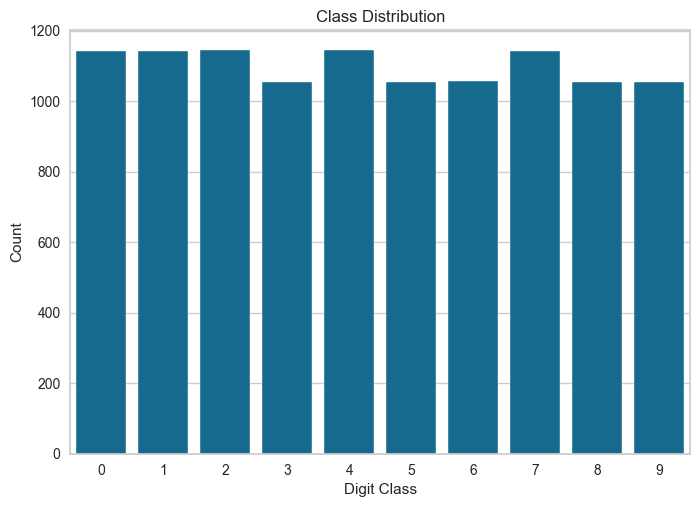

In [16]:
plt.figure()
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.xlabel("Digit Class")
plt.ylabel("Count")
plt.show()

Class Distribution: The dataset shows a relatively balanced distribution across all digit classes (0–9), which is important for building unbiased classification models.

**Dataset Overview**  
The dataset was successfully loaded and contains X rows and Y columns.  
Each row represents a handwritten digit instance described by 16 numerical features (input1–input16), which correspond to the x-y coordinates of the digit trajectory.  
Initial inspection shows:     
-No missing values in the dataset   
-No duplicate records detected  
-All features are numerical and suitable for machine learning models    
Basic statistical analysis indicates that feature values range between 0 and 100, which is expected for coordinate-based inputs.   
The target variable (`class`) represents digits from 0 to 9.

## Explore Data

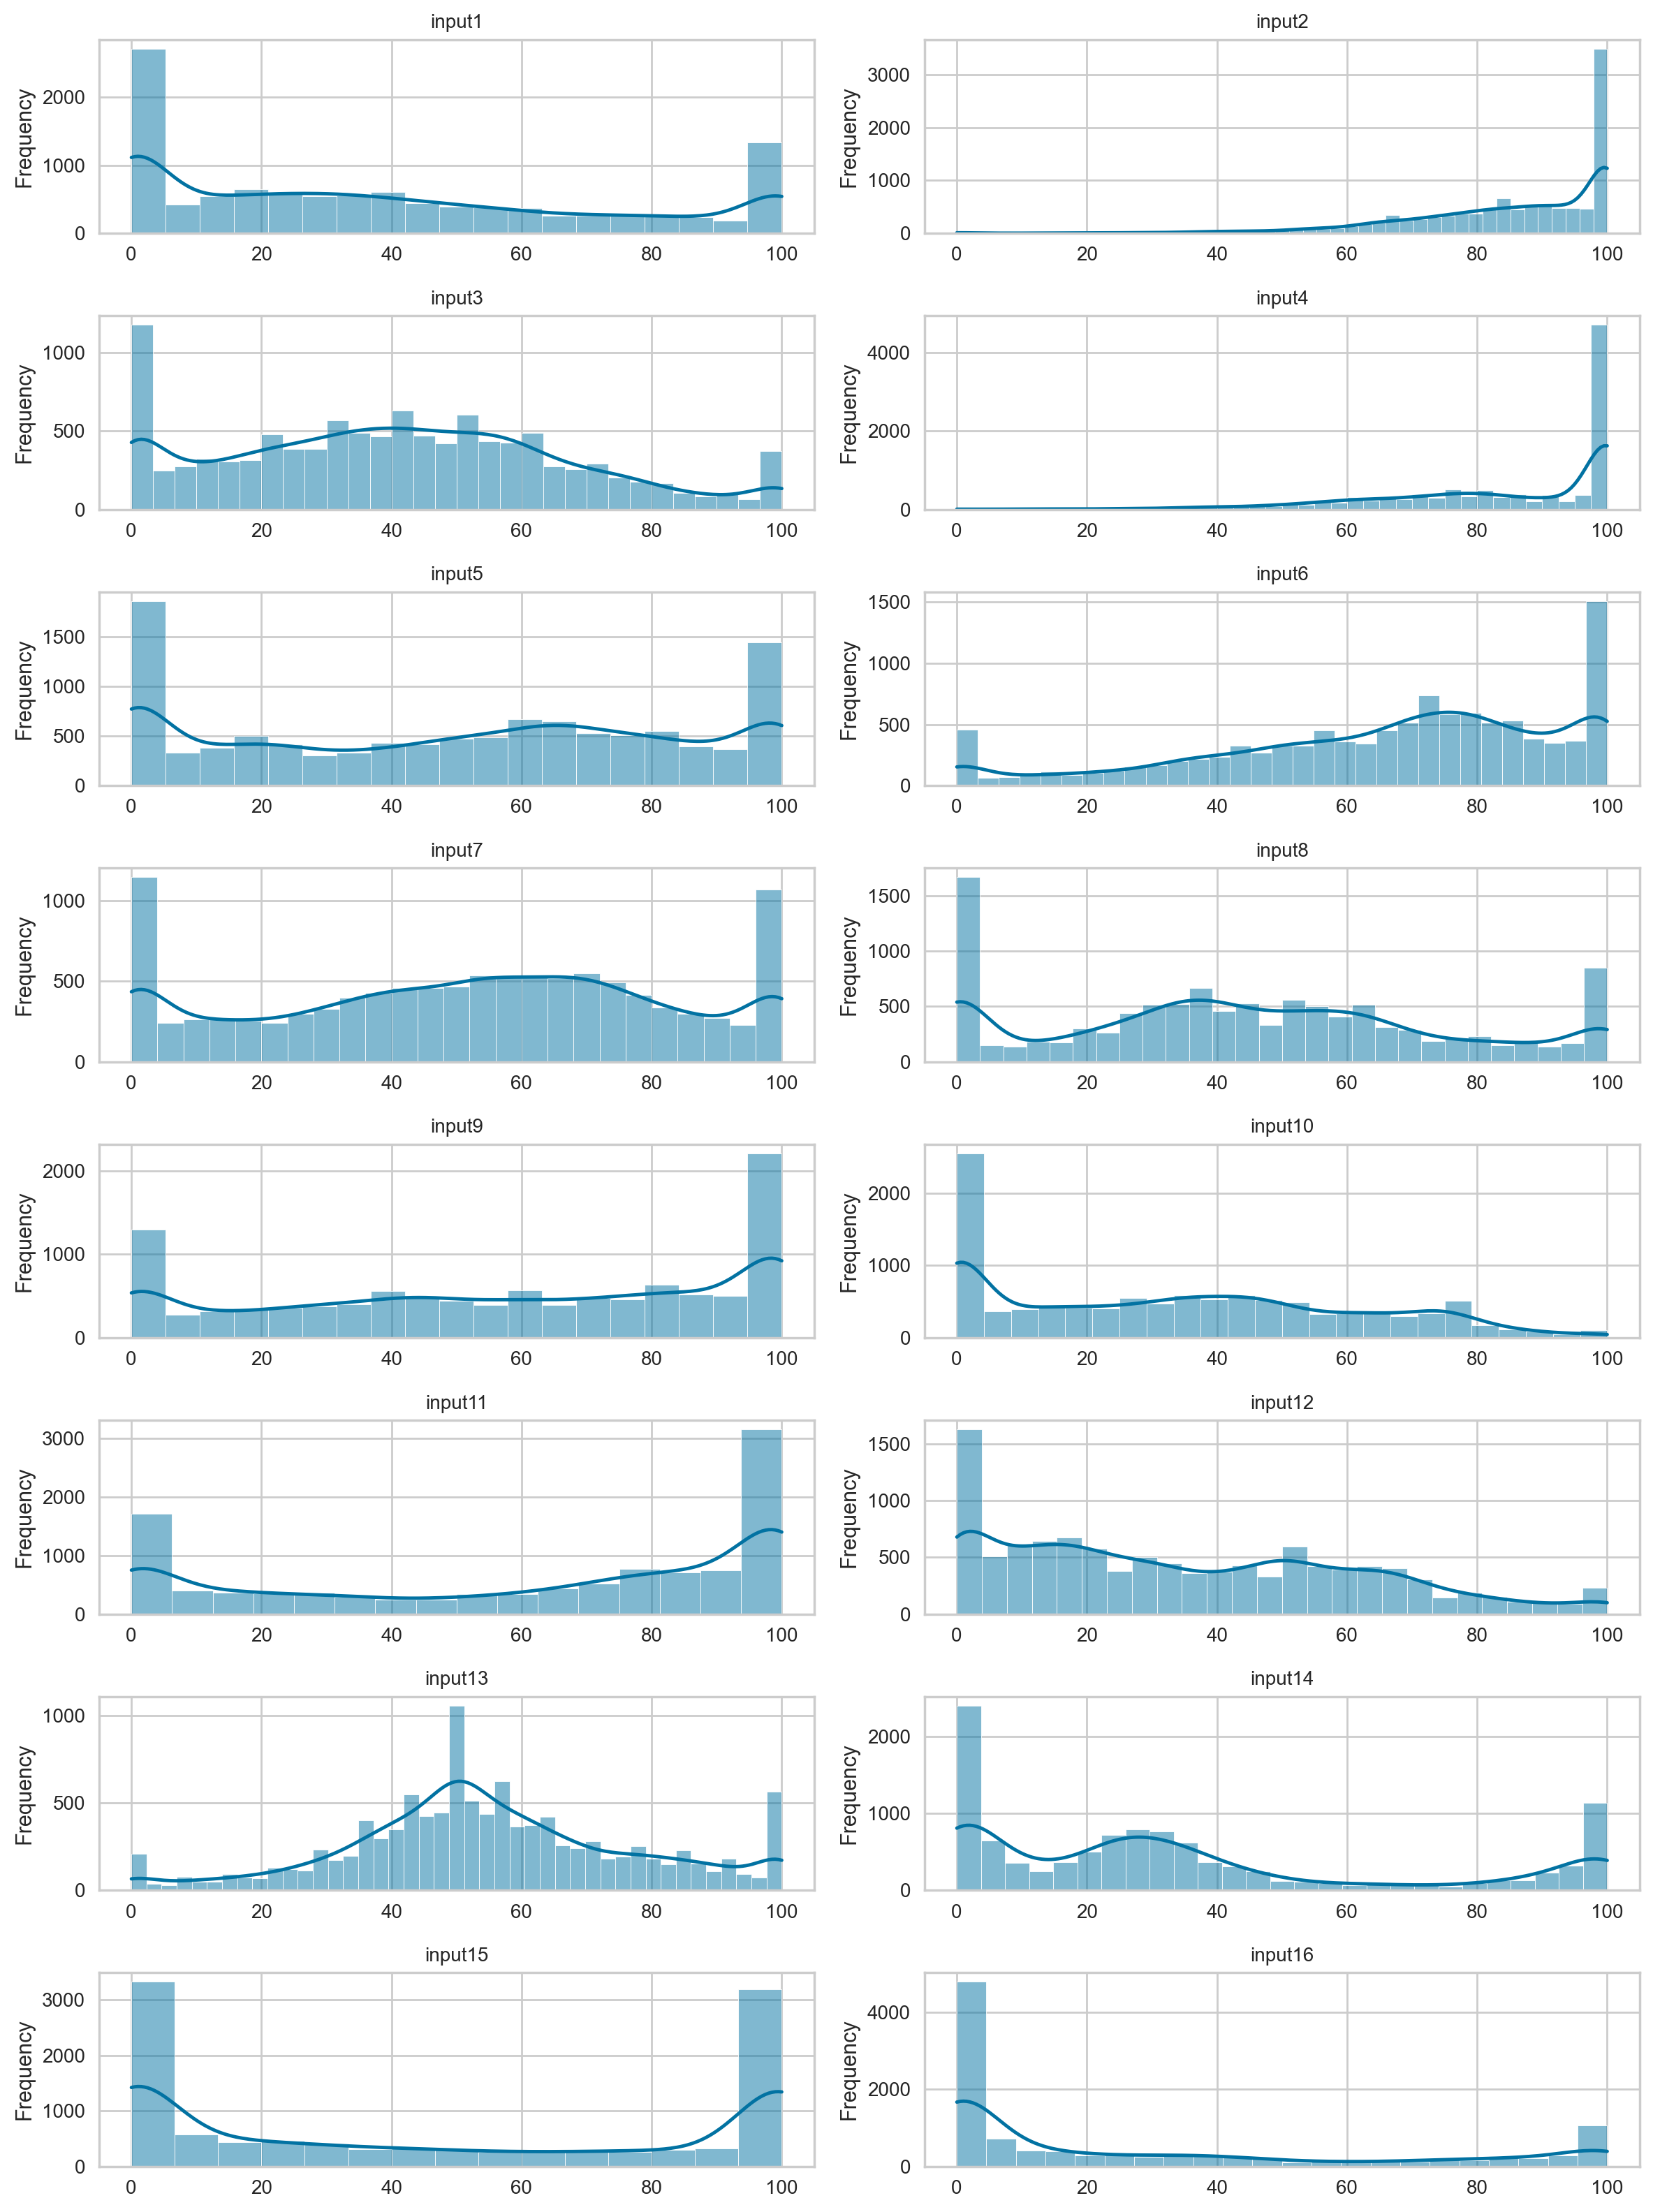

In [20]:
# Exploring feature distributions across all input variables

fig = plt.figure(figsize=(12, 16), dpi=200)

for i, col in enumerate(df.columns[:-1]):
    plt.subplot(8, 2, i + 1)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(col, fontsize=10)
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Feature Distribution Analysis**   
The exploratory data analysis confirms that the dataset is clean and well-structured, with no missing values or major inconsistencies. Feature distribution plots reveal that many variables are not normally distributed and exhibit skewness, with several features showing concentration around extreme values (close to 0 or 100). This suggests that the data reflects boundary patterns of handwritten digit trajectories.  
Despite noticeable overlaps in distributions, distinct patterns across features suggest that the dataset contains sufficient information for class differentiation. Overall, the presence of non-linear patterns and overlapping distributions indicates that advanced models such as SVM and ensemble methods are more suitable for achieving high classification performance.

## Data Cleaning

### Detect Missing Values and Outliers

In [24]:
# Missing Values
print("Missing values per column:\n", df.isnull().sum())

# there are no missing values in the dataset, meaning that no imputation or data filling techniques are required

Missing values per column:
 input1     0
input2     0
input3     0
input4     0
input5     0
input6     0
input7     0
input8     0
input9     0
input10    0
input11    0
input12    0
input13    0
input14    0
input15    0
input16    0
class      0
dtype: int64


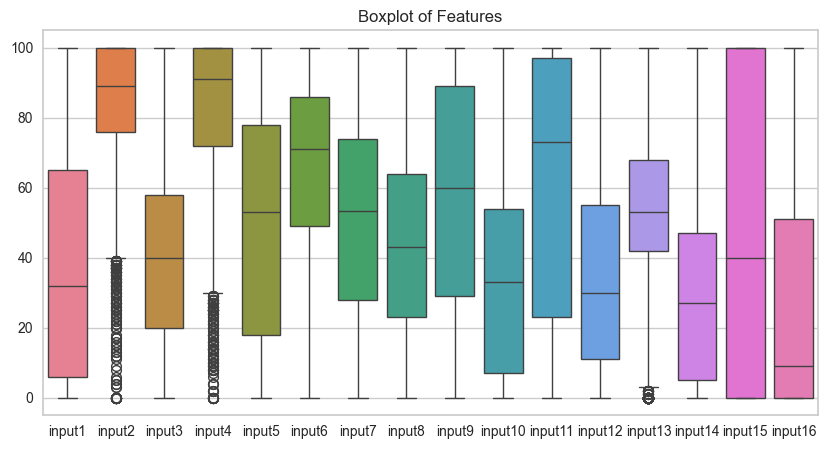

In [25]:
# Outlier Detection

plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop("class", axis=1))
plt.title("Boxplot of Features")
plt.show()

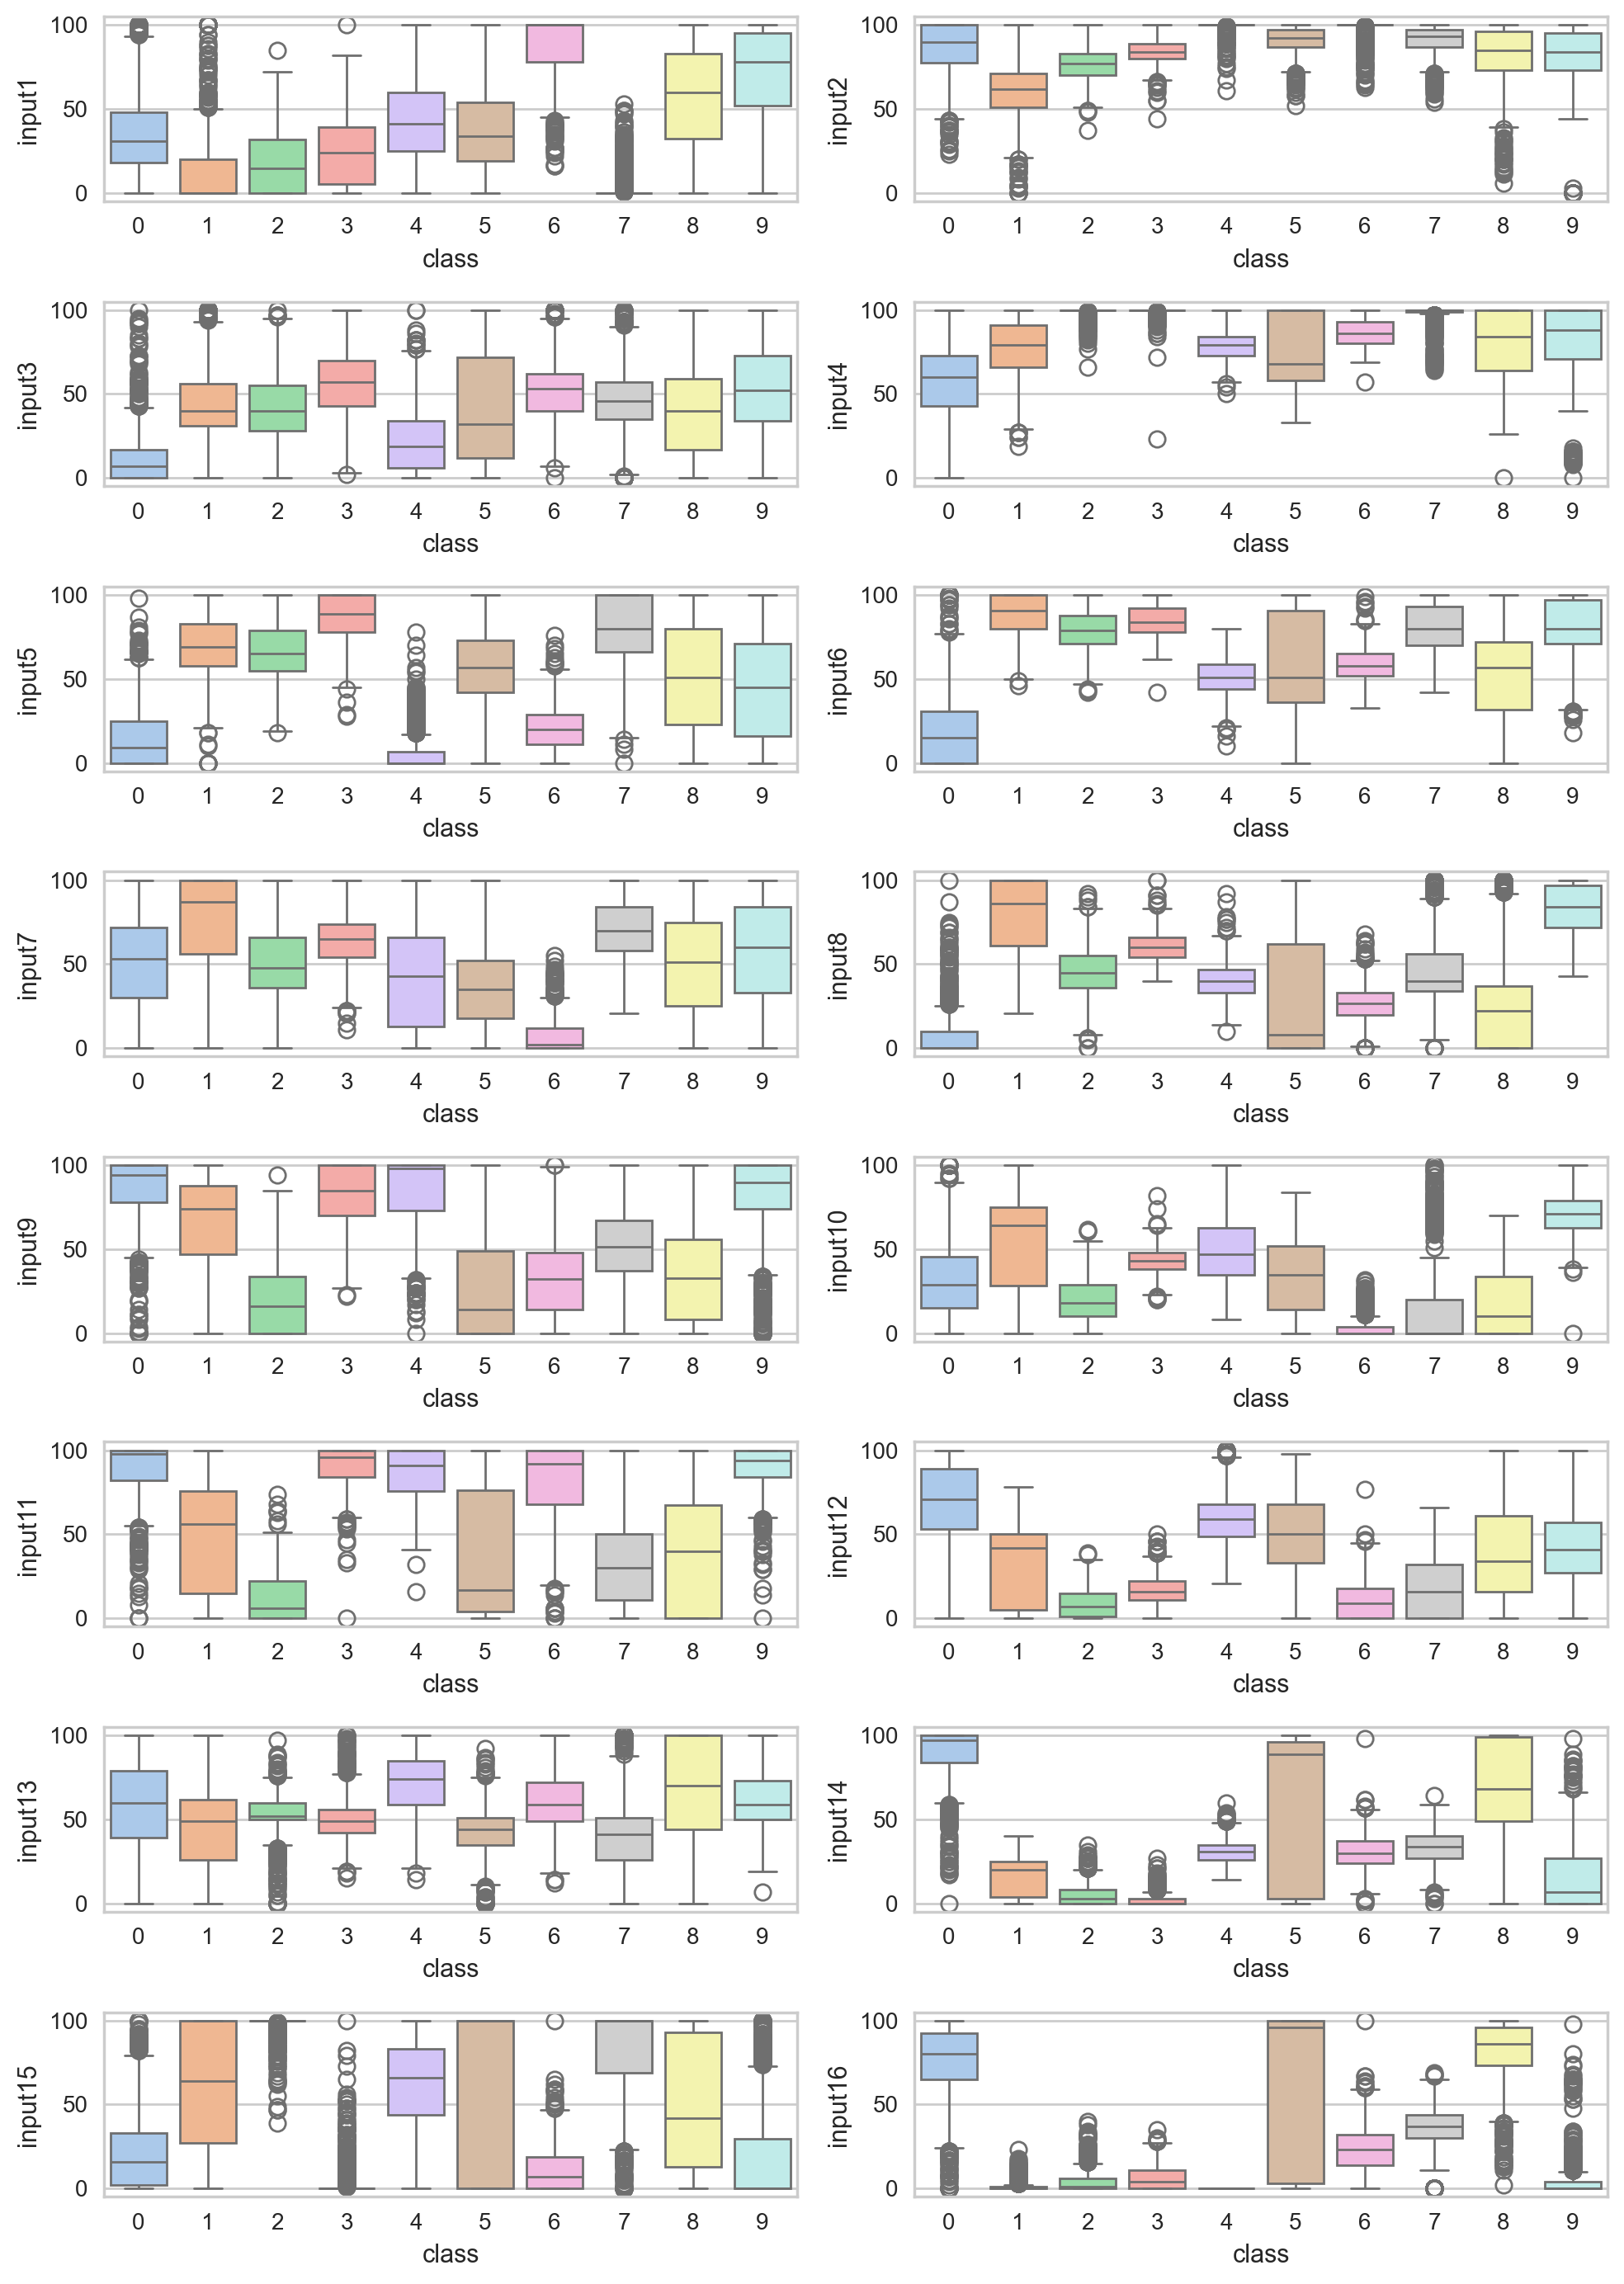

In [26]:
# The boxplot of each feature by class
fig = plt.figure(figsize=(10,14), dpi=200)

for i, col in enumerate(df.columns[:-1]):
    plt.subplot(8,2,i+1)
    sns.boxplot(
        y=df[col],
        x=df["class"],
        data=df,
        palette="pastel"
    )

plt.tight_layout()

In [27]:
# Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered potential outliers
# Outlier detection is performed for each feature independently, excluding the target variable
def get_outlier_bounds(df, col, k=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    
    return lower, upper

In [28]:
# setting the threshold as 1.5 

outlier_cols = []

for col in df.columns[:-1]:  # exclude target
    lower, upper = get_outlier_bounds(df, col)
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    if len(outliers) > 0:
        outlier_cols.append(col)

print("Columns with outliers:", outlier_cols)

Columns with outliers: ['input2', 'input4', 'input13']


### Target Variable Distribution

In [30]:
# The distribution of the target variable (class) to ensure that the classes are reasonably balanced
# A balanced target distribution helps reduce the risk of model bias toward specific classes
class_distribution = df["class"].value_counts().sort_index().reset_index()
class_distribution.columns = ["class", "count"]
class_distribution

,class,count
0,0,1143
1,1,1143
2,2,1144
3,3,1055
4,4,1144
5,5,1055
6,6,1056
7,7,1142
8,8,1055
9,9,1055


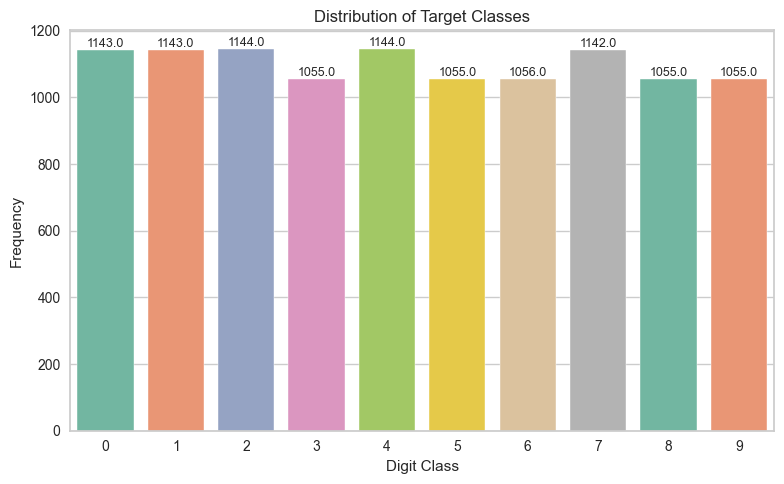

In [31]:
# Distribution of Target Classes

plt.figure(figsize=(8,5))
ax = sns.countplot(x="class", data=df, palette="Set2")

plt.title("Distribution of Target Classes")
plt.xlabel("Digit Class")
plt.ylabel("Frequency")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height()}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [32]:
# istribution of Target Classes (percentage)

class_summary = pd.DataFrame({
    "count": df["class"].value_counts().sort_index(),
    "percentage": round(df["class"].value_counts(normalize=True).sort_index() * 100, 2)
})
class_summary

,count,percentage
class,,
0,1143,10.40
1,1143,10.40
2,1144,10.41
3,1055,9.60
4,1144,10.41
5,1055,9.60
6,1056,9.61
7,1142,10.39
8,1055,9.60


**Target Variable Distribution**   
The target variable represents handwritten digit classes from 0 to 9.   
The class distribution shows that the dataset is reasonably balanced. The target variable is well distributed across all ten digit classes.    
The analysis indicates that the dataset is sufficiently balanced for classification, meaning that no additional balancing techniques are required before model development.

###   Correlation Analysis

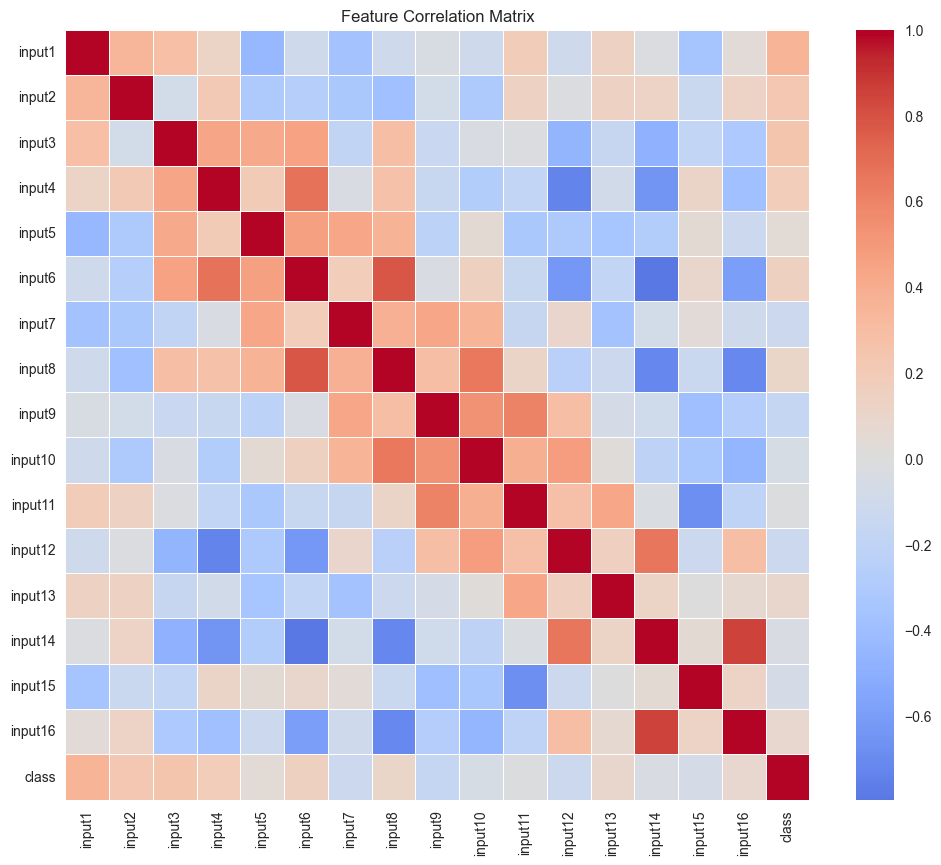

In [35]:
# Correlation analysis helps identify dependencies between variables and detect potential multicollinearity
corr_matrix = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

**Correlation Analysis**    
Correlation values range from -1 to 1, where values close to ±1 indicate strong relationships, and values close to 0 indicate weak or no relationship.   Multicollinearity occurs when features are highly correlated with each other, which can negatively affect some models.

# Multi-class Classification

### Data Preprocessing

In [39]:
df = pd.read_csv("handdigit_EDA.csv")
df.head()

,input1,input2,input3,input4,input5,input6,input7,input8,input9,input10,input11,input12,input13,input14,input15,input16,class
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1


In [40]:
X = df.drop("class", axis = 1)
y = df["class"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

**Train-test split**  
The dataset is split without shuffling (`shuffle=False`) to preserve the original data structure. Shuffling could lead to potential data leakage, where very similar handwritten digit patterns may appear in both training and test sets, resulting in overly optimistic model performance. By keeping the original order, the risk of overlap between training and testing samples is reduced, ensuring a more reliable evaluation. This approach is particularly relevant when observations may share underlying similarities, even if the data is not strictly time-based.

## Implement Support Vector Machine



### Vanilla SVC

In [45]:
scaler = MinMaxScaler()           
# The Support Vector Classifier (SVC) with an RBF kernel was used as a baseline model for multi-class classification
# SVM is a powerful algorithm that aims to find the optimal decision boundary by maximizing the margin between classes

In [46]:
SVM_model =  SVC(kernel="rbf", random_state=101)
# The RBF (Radial Basis Function) kernel maps the data into a higher-dimensional space, allowing the model to capture non-linear relationships
# This makes SVM particularly effective for datasets where classes are not linearly separable

In [47]:
from sklearn.pipeline  import Pipeline

SVM_model = Pipeline([("scaler",scaler),("SVM",SVM_model)])

In [48]:
SVM_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('SVM', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [49]:
y_pred_test = SVM_model.predict(X_test)
y_pred_train = SVM_model.predict(X_train)

# Feature scaling was applied using MinMaxScaler, as SVM is sensitive to the magnitude of input features
# A pipeline was used to ensure that scaling and model training are applied consistently and without data leakage

In [50]:
SVM_accuracy_test = accuracy_score(y_test, y_pred_test)
SVM_accuracy_train = accuracy_score(y_train, y_pred_train)

svm_f1_test = f1_score(y_test, y_pred_test, average='macro')
svm_f1_train = f1_score(y_train, y_pred_train, average='macro')

SVM_accuracy_test, SVM_accuracy_train, svm_f1_test, svm_f1_train

#  Мodel performance was evaluated using accuracy and macro-averaged F1-score on both training and test sets
#  This allows assessment of both overall performance and class-wise balance

(0.990450204638472, 0.995678380529967, 0.9904537211561903, 0.9956930837146494)

In [51]:
print("TEST CM\n" , confusion_matrix(y_test, y_pred_test))
print("-*"*30)
print("TRAIN CM \n", confusion_matrix(y_train, y_pred_train))

print("TEST REPORT \n", classification_report(y_test, y_pred_test, digits= 3))
print("-*"*30)
print("TRAIN REPORT \n", classification_report(y_train, y_pred_train, digits= 3))


TEST CM
 [[219   0   0   0   0   0   0   0   2   0]
 [  0 224   4   0   0   0   0   1   0   0]
 [  0   1 224   0   0   0   0   0   0   0]
 [  0   0   0 218   0   0   0   0   0   1]
 [  0   0   0   0 240   2   0   0   0   0]
 [  0   0   0   3   0 205   0   0   0   2]
 [  0   0   0   0   0   0 210   0   0   0]
 [  0   1   0   0   0   0   0 221   0   0]
 [  0   0   0   0   0   0   0   0 199   0]
 [  0   0   0   0   0   0   0   3   1 218]]
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
TRAIN CM 
 [[920   1   0   0   0   0   1   0   0   0]
 [  0 901   6   5   1   0   0   1   0   0]
 [  0   3 915   0   0   0   0   1   0   0]
 [  0   1   2 830   0   1   0   1   0   1]
 [  0   0   0   0 899   2   0   1   0   0]
 [  0   0   0   2   0 840   0   0   1   2]
 [  0   0   0   0   0   1 845   0   0   0]
 [  0   1   0   0   0   0   0 919   0   0]
 [  0   0   0   0   0   1   0   1 854   0]
 [  0   0   0   0   0   0   0   1   0 832]]
TEST REPORT 
               precision    recall  f1-score

**Conclusion - Vanilla SVC**   
The SVM model demonstrates excellent performance, achieving approximately 99% accuracy on the test set and 99.6% on the training set.  
The small difference between training and test results indicates strong generalization ability with minimal overfitting.    
Class-wise metrics (precision, recall, and F1-score) are consistently high across all classes, confirming that the model performs reliably and maintains balanced predictions.    
Overall, the RBF-based SVM proves to be highly effective for this multi-class classification task.

###   SVC GridsearchCV

In [54]:
# Pipeline
svm_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svc", SVC(kernel="rbf", probability=True))
])

# Hyperparameter grid
param_grid = {
    "svc__C": np.linspace(1.0, 1.3, 10),
    "svc__gamma": ["scale", "auto"]
}

# Grid search
svm_grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

# To improve the baseline SVM model, hyperparameter tuning was performed using GridSearchCV
# GridSearchCV systematically evaluates multiple parameter combinations using cross-validation and selects the configuration that produces the best performance
# The parameter `C` controls the trade-off between margin maximization and classification error
# The parameter `gamma` determines how far the influence of a single training example reaches
# Cross-validation helps produce a more reliable estimate of model performance during tuning

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ility=True))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__C': array([1. ..., 1.3 ]), 'svc__gamma': ['scale', 'auto']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also di

In [55]:
print("Best parameters:", svm_grid.best_params_)
print("Best cross-validation score:", round(svm_grid.best_score_, 4))

Best parameters: {'svc__C': 1.3, 'svc__gamma': 'scale'}
Best cross-validation score: 0.9937


In [56]:
# Predictions
y_pred_test = svm_grid.predict(X_test)
y_pred_train = svm_grid.predict(X_train)

# Performance metrics
svm_acc_test = accuracy_score(y_test, y_pred_test)
svm_acc_train = accuracy_score(y_train, y_pred_train)

svm_f1_test = f1_score(y_test, y_pred_test, average="macro")
svm_f1_train = f1_score(y_train, y_pred_train, average="macro")

print("Test Accuracy:", round(svm_acc_test, 4))
print("Train Accuracy:", round(svm_acc_train, 4))
print("Test Macro F1:", round(svm_f1_test, 4))
print("Train Macro F1:", round(svm_f1_train, 4))

Test Accuracy: 0.9923
Train Accuracy: 0.9964
Test Macro F1: 0.9923
Train Macro F1: 0.9964


**Performance metrics**    
The tuned SVM model achieved approximately **99.23% accuracy** on the test set and **99.64% accuracy** on the training set.
The macro F1-scores are also very high and closely aligned with the accuracy values, indicating balanced performance across all classes.
The small gap between training and test results suggests that the tuned model generalizes well and does not show significant overfitting.

In [58]:
print("TEST CONFUSION MATRIX\n", confusion_matrix(y_test, y_pred_test))
print("-" * 50)
print("TRAIN CONFUSION MATRIX\n", confusion_matrix(y_train, y_pred_train))

print("\nTEST CLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred_test, digits=3))

print("-" * 50)
print("TRAIN CLASSIFICATION REPORT\n")
print(classification_report(y_train, y_pred_train, digits=3))

TEST CONFUSION MATRIX
 [[220   0   0   0   0   0   0   0   1   0]
 [  0 225   3   0   0   0   0   1   0   0]
 [  0   1 224   0   0   0   0   0   0   0]
 [  0   0   0 218   0   0   0   0   0   1]
 [  0   0   0   0 241   1   0   0   0   0]
 [  0   0   0   3   0 206   0   0   0   1]
 [  0   0   0   0   0   0 210   0   0   0]
 [  0   1   0   0   0   0   0 221   0   0]
 [  0   0   0   0   0   0   0   0 199   0]
 [  0   0   0   0   0   0   0   3   1 218]]
--------------------------------------------------
TRAIN CONFUSION MATRIX
 [[920   1   0   0   0   0   1   0   0   0]
 [  0 902   6   4   1   0   0   1   0   0]
 [  0   1 917   0   0   0   0   1   0   0]
 [  0   1   2 830   0   1   0   1   0   1]
 [  0   0   0   0 902   0   0   0   0   0]
 [  0   0   0   2   0 840   0   0   1   2]
 [  0   0   0   0   0   1 845   0   0   0]
 [  0   1   0   0   0   0   0 919   0   0]
 [  0   0   0   0   0   1   0   1 854   0]
 [  0   0   0   0   0   0   0   1   0 832]]

TEST CLASSIFICATION REPORT

           

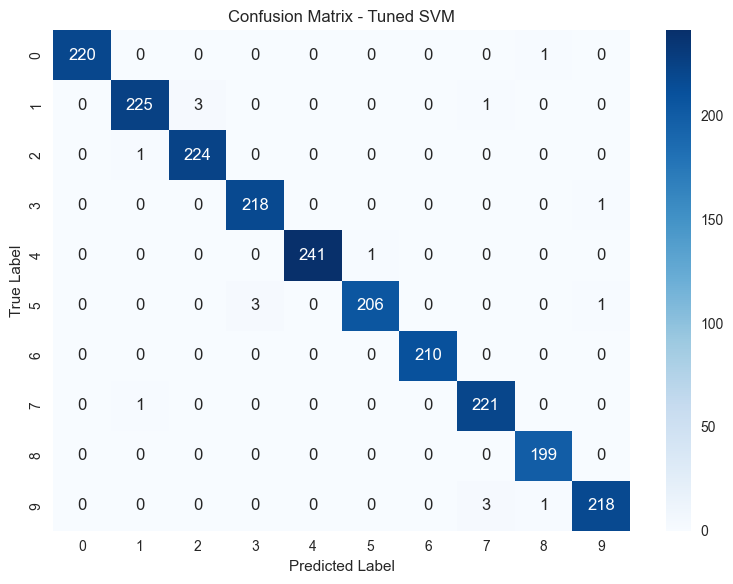

In [59]:
# Сlass-wise Prediction Error Analysis
# To examine how the tuned SVM model performs across individual classes, a class prediction error visualization was generated
# This plot helps identify which digit classes are predicted most accurately and where misclassifications occur more often

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Predictions from the tuned SVM model
y_pred_test = svm_grid.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Convert to DataFrame for better visualization
cm_df = pd.DataFrame(cm, index=range(10), columns=range(10))

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Tuned SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**Class-wise Prediction Error Analysis**  
The confusion matrix shows that most predictions are concentrated along the diagonal, indicating that the tuned SVM model correctly classifies the majority of handwritten digits. Only a small number of errors appear between a few classes, which suggests that the model performs strongly overall, with limited confusion between visually similar digit patterns.

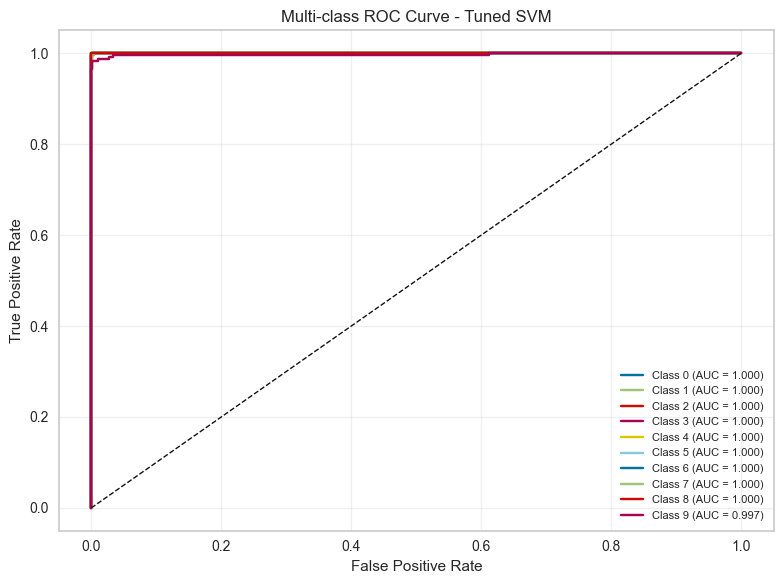

In [201]:
# Binarize the labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=range(10))

# Predict probabilities
y_pred_proba = svm_grid.predict_proba(X_test)

# Number of classes
n_classes = y_test_bin.shape[1]

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve - Tuned SVM")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Multi-class ROC Curve - Tuned SVM**: The ROC curves demonstrate that the tuned SVM model achieves very high AUC values across all classes. This indicates excellent class separability and confirms that the model performs consistently well in distinguishing between different handwritten digits.

In [ ]:
roc_auc_macro = roc_auc_score(y_test_bin, y_pred_proba, average="macro", multi_class="ovr")
print("Macro-average ROC AUC:", round(roc_auc_macro, 4))

In [ ]:
# Predict class probabilities for the test set
y_pred_proba = svm_grid.predict_proba(X_test)

# Calculate log loss (cross-entropy loss)
svm_log_loss = log_loss(y_test, y_pred_proba)

# Display result
print("Log Loss (Test Set):", round(svm_log_loss, 4))

In [ ]:
# Train log loss
y_train_proba = svm_grid.predict_proba(X_train)
svm_log_loss_train = log_loss(y_train, y_train_proba)

print("Log Loss (Train):", round(svm_log_loss_train, 4))
print("Log Loss (Test):", round(svm_log_loss, 4))

Log Loss Evaluation:    
The log loss value is very low (approximately 0.033), indicating that the model produces highly confident and well-calibrated predictions. This confirms that the tuned SVM model is not only accurate, but also reliable in terms of probability estimation. The log loss values for both training and test sets are very close, which indicates that the model is well-generalized and does not suffer from overfitting.

**Overall Conclusion - Support Vector Machine**    
The SVM models demonstrated excellent performance in the multi-class handwritten digit classification task.  
Both the baseline SVC and the tuned SVC with GridSearchCV achieved very high accuracy and macro F1-scores, indicating strong and balanced classification across all digit classes. The tuned model provided a slight improvement over the baseline, confirming the benefit of hyperparameter optimization.   
Additional evaluation using the confusion matrix, ROC-AUC analysis, and log loss further showed that the optimized SVM model is highly reliable, with strong class separability, low misclassification rates, and well-calibrated predicted probabilities.   
Overall, SVM proved to be one of the most effective models for this dataset and provided robust generalization with minimal signs of overfitting.

## Implement Decision Tree Classifier

### Vanilla DT

In [68]:
from sklearn.tree import DecisionTreeClassifier

# A baseline Decision Tree Classifier was implemented to evaluate its performance on the handwritten digit classification task
# Decision Trees are simple and interpretable models that split the data based on feature values in order to classify observations
    
# Train a baseline Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [70]:
# Generate predictions
y_pred_test_dt = dt_model.predict(X_test)
y_pred_train_dt = dt_model.predict(X_train)

In [78]:
from sklearn.metrics import accuracy_score, f1_score

# Evaluate model performance
dt_accuracy_test = accuracy_score(y_test, y_pred_test_dt)
dt_accuracy_train = accuracy_score(y_train, y_pred_train_dt)

dt_f1_test = f1_score(y_test, y_pred_test_dt, average="macro")
dt_f1_train = f1_score(y_train, y_pred_train_dt, average="macro")

print("Decision Tree Test Accuracy:", round(dt_accuracy_test, 4))
print("Decision Tree Train Accuracy:", round(dt_accuracy_train, 4))
print("Decision Tree Test Macro F1:", round(dt_f1_test, 4))
print("Decision Tree Train Macro F1:", round(dt_f1_train, 4))

# The baseline Decision Tree achieved approximately 95.13 accuracy on the test set and 100% accuracy on the training set   
# The same pattern is observed for the macro F1-score, indicating that the model fits the training data perfectly but performs noticeably worse on unseen data  
# This suggests that the baseline Decision Tree suffers from overfitting  

Decision Tree Test Accuracy: 0.9513
Decision Tree Train Accuracy: 1.0
Decision Tree Test Macro F1: 0.9513
Decision Tree Train Macro F1: 1.0


In [80]:
from sklearn.metrics import confusion_matrix, classification_report

print("TEST CONFUSION MATRIX\n", confusion_matrix(y_test, y_pred_test_dt))
print("-" * 50)
print("TRAIN CONFUSION MATRIX\n", confusion_matrix(y_train, y_pred_train_dt))

print("\nTEST CLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred_test_dt, digits=3))

print("-" * 50)
print("TRAIN CLASSIFICATION REPORT\n")
print(classification_report(y_train, y_pred_train_dt, digits=3))

TEST CONFUSION MATRIX
 [[218   0   0   0   1   0   0   0   2   0]
 [  0 212  16   0   0   0   0   1   0   0]
 [  0   3 216   0   0   1   0   3   0   2]
 [  0   6   1 207   0   3   0   0   0   2]
 [  0   0   0   0 238   2   1   0   0   1]
 [  0   0   1   6   2 194   2   0   0   5]
 [  4   1   1   0   0   0 200   1   3   0]
 [  0   8   2   1   0   1   4 204   1   1]
 [  2   0   0   0   0   1   0   0 196   0]
 [  0   0   0   4   3   3   1   3   1 207]]
--------------------------------------------------
TRAIN CONFUSION MATRIX
 [[922   0   0   0   0   0   0   0   0   0]
 [  0 914   0   0   0   0   0   0   0   0]
 [  0   0 919   0   0   0   0   0   0   0]
 [  0   0   0 836   0   0   0   0   0   0]
 [  0   0   0   0 902   0   0   0   0   0]
 [  0   0   0   0   0 845   0   0   0   0]
 [  0   0   0   0   0   0 846   0   0   0]
 [  0   0   0   0   0   0   0 920   0   0]
 [  0   0   0   0   0   0   0   0 856   0]
 [  0   0   0   0   0   0   0   0   0 833]]

TEST CLASSIFICATION REPORT

           

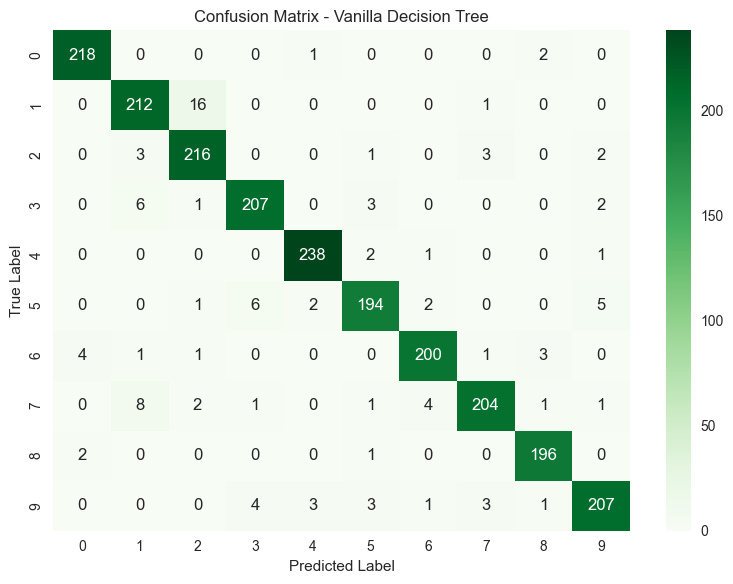

In [82]:
# Confusion matrix heatmap for test set
cm_dt = confusion_matrix(y_test, y_pred_test_dt)
cm_dt_df = pd.DataFrame(cm_dt, index=range(10), columns=range(10))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_df, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - Vanilla Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**Confusion matrix**: The confusion matrix shows that the Decision Tree correctly classifies many observations, but the number of misclassifications is higher than in the SVM model. This indicates that while the model captures the main structure of the dataset, it is less robust when generalizing to unseen handwritten digit patterns.

**Conclusion - Vanilla Decision Tree**:    
The baseline Decision Tree produced reasonably strong test performance, but the perfect training accuracy combined with lower test accuracy indicates clear overfitting. Although the model is simple and interpretable, its generalization ability is weaker than that of the SVM model.

### DT GridsearchCV

In [89]:
# To reduce overfitting and improve the baseline Decision Tree model, hyperparameter tuning was performed using GridSearchCV
#  GridSearchCV evaluates multiple parameter combinations through cross-validation and selects the model with the best validation performance

# The `criterion` parameter controls how the quality of a split is measured
# The `max_depth` parameter limits the depth of the tree and helps reduce overfitting
# The `max_features` parameter controls how many features are considered at each split
# The `max_leaf_nodes` parameter limits the number of terminal nodes and improves model generalization

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [7, 8],
    "max_features": [0.8],
    "max_leaf_nodes": [180, 200]
}

# Base model
dt_base = DecisionTreeClassifier(random_state=42)

# Grid search
dt_grid = GridSearchCV(
    estimator=dt_base,
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [7, 8], 'max_features': [0.8], 'max_leaf_nodes': [180, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [93]:
print("Best parameters:", dt_grid.best_params_)
print("Best cross-validation score:", round(dt_grid.best_score_, 4))

# The optimal Decision Tree configuration selected by GridSearchCV was:
# criterion = entropy
# max_depth = 8
# max_features = 0.8
# max_leaf_nodes = 180
# These settings were chosen to improve generalization and reduce the overfitting observed in the baseline tree

Best parameters: {'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.8, 'max_leaf_nodes': 180}
Best cross-validation score: 0.9469


In [99]:
from sklearn.metrics import accuracy_score, f1_score

# Predictions
y_pred_test_dt_grid = dt_grid.predict(X_test)
y_pred_train_dt_grid = dt_grid.predict(X_train)

# Performance metrics
dt_grid_accuracy_test = accuracy_score(y_test, y_pred_test_dt_grid)
dt_grid_accuracy_train = accuracy_score(y_train, y_pred_train_dt_grid)

dt_grid_f1_test = f1_score(y_test, y_pred_test_dt_grid, average="macro")
dt_grid_f1_train = f1_score(y_train, y_pred_train_dt_grid, average="macro")

print("Tuned DT Test Accuracy:", round(dt_grid_accuracy_test, 4))
print("Tuned DT Train Accuracy:", round(dt_grid_accuracy_train, 4))
print("Tuned DT Test Macro F1:", round(dt_grid_f1_test, 4))
print("Tuned DT Train Macro F1:", round(dt_grid_f1_train, 4))   


# The tuned Decision Tree achieved approximately 93.18% accuracy on the test set and 96.83% accuracy on the training set  
# Compared with the baseline Decision Tree, the tuned model shows a smaller gap between training and test performance, indicating that overfitting was reduced  
# However, the overall test accuracy is slightly lower than that of the baseline model, suggesting that the regularization improved generalization control but also reduced predictive performance.

Tuned DT Test Accuracy: 0.9318
Tuned DT Train Accuracy: 0.9683
Tuned DT Test Macro F1: 0.9329
Tuned DT Train Macro F1: 0.9683


In [101]:
from sklearn.metrics import confusion_matrix, classification_report

print("TEST CONFUSION MATRIX\n", confusion_matrix(y_test, y_pred_test_dt_grid))
print("-" * 50)
print("TRAIN CONFUSION MATRIX\n", confusion_matrix(y_train, y_pred_train_dt_grid))

print("\nTEST CLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred_test_dt_grid, digits=3))

print("-" * 50)
print("TRAIN CLASSIFICATION REPORT\n")
print(classification_report(y_train, y_pred_train_dt_grid, digits=3))

TEST CONFUSION MATRIX
 [[217   0   0   0   1   0   0   0   3   0]
 [  0 208  19   1   0   0   0   1   0   0]
 [  0  31 186   6   0   0   2   0   0   0]
 [  0   4   0 212   0   3   0   0   0   0]
 [  0   8   0   0 229   1   1   0   0   3]
 [  0   1   0  11   0 189   0   1   1   7]
 [  1   2   0   3   0   2 202   0   0   0]
 [  0   5   3   2   0   1   1 209   1   0]
 [  2   0   0   0   0   1   0   0 196   0]
 [  1   1   0   5   2   9   0   3   0 201]]
--------------------------------------------------
TRAIN CONFUSION MATRIX
 [[920   0   1   0   1   0   0   0   0   0]
 [  0 861  33  14   0   0   0   3   0   3]
 [  0  65 844   9   0   0   0   0   0   1]
 [  0   6   2 815   0  11   0   2   0   0]
 [  0   2   0   0 892   4   0   0   0   4]
 [  0   0   0  31   0 793   0   1   0  20]
 [  0   0   0   1   2   5 837   1   0   0]
 [  0   3   3   6   0   0   0 908   0   0]
 [  1   0   2   2   0   1   0   0 850   0]
 [  0   2   0   4   4  29   0   0   0 794]]

TEST CLASSIFICATION REPORT

           

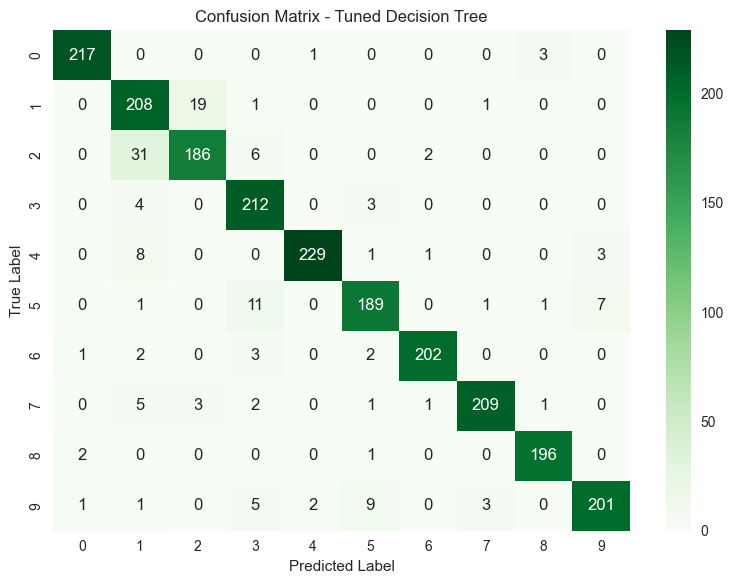

In [107]:
# Confusion matrix for tuned Decision Tree
cm_dt_grid = confusion_matrix(y_test, y_pred_test_dt_grid)
cm_dt_grid_df = pd.DataFrame(cm_dt_grid, index=range(10), columns=range(10))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_grid_df, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# The confusion matrix shows that the tuned Decision Tree still classifies most digits correctly, although more classification errors are visible compared with the SVM model   
# This indicates that the tuned tree is more controlled than the baseline version, but still less accurate overall in distinguishing similar handwritten digit patterns

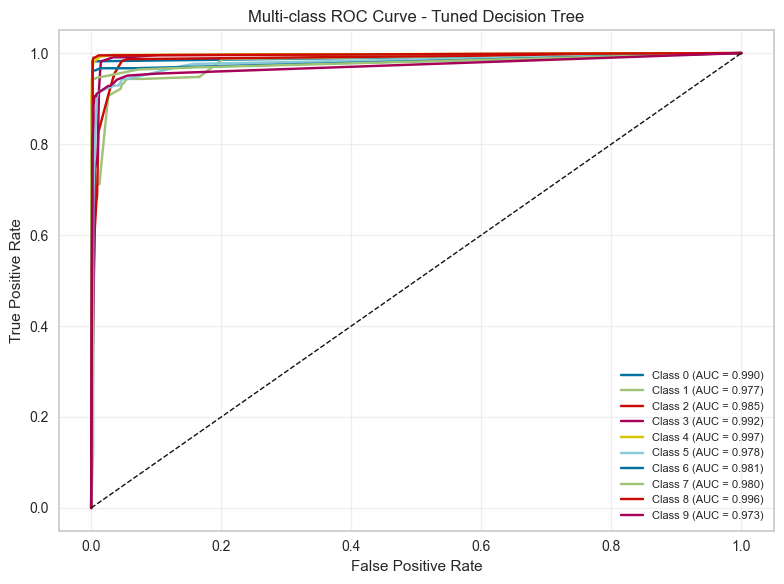

Macro-average ROC AUC: 0.985


In [117]:
# Binarize test labels
y_test_bin = label_binarize(y_test, classes=range(10))

# Predicted probabilities
y_pred_proba_dt = dt_grid.predict_proba(X_test)

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve - Tuned Decision Tree")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Macro-average ROC-AUC
dt_roc_auc_macro = roc_auc_score(y_test_bin, y_pred_proba_dt, average="macro", multi_class="ovr")
print("Macro-average ROC AUC:", round(dt_roc_auc_macro, 4))

**Conclusion - DT GridsearchCV**:  
Hyperparameter tuning reduced the overfitting observed in the baseline Decision Tree model by limiting model complexity. However, this improvement in generalization control came at the cost of slightly lower test performance. As a result, the tuned Decision Tree is more stable than the vanilla version, but still less effective than the SVM model for this handwritten digit classification task.

## Implement Random Forest Classifier


### Vanilla RF

In [124]:
# A baseline Random Forest Classifier was implemented to evaluate its performance on the handwritten digit classification task
# Random Forest is an ensemble learning method that combines multiple decision trees in order to improve predictive accuracy and reduce overfitting

from sklearn.ensemble import RandomForestClassifier

# Train a baseline Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [128]:
# Generate predictions
y_pred_test_rf = rf_model.predict(X_test)
y_pred_train_rf = rf_model.predict(X_train)

In [134]:
from sklearn.metrics import accuracy_score, f1_score

# Evaluate model performance
rf_accuracy_test = accuracy_score(y_test, y_pred_test_rf)
rf_accuracy_train = accuracy_score(y_train, y_pred_train_rf)

rf_f1_test = f1_score(y_test, y_pred_test_rf, average="macro")
rf_f1_train = f1_score(y_train, y_pred_train_rf, average="macro")

print("Random Forest Test Accuracy:", round(rf_accuracy_test, 4))
print("Random Forest Train Accuracy:", round(rf_accuracy_train, 4))
print("Random Forest Test Macro F1:", round(rf_f1_test, 4))
print("Random Forest Train Macro F1:", round(rf_f1_train, 4))


# The baseline Random Forest achieved approximately 98.45% accuracy on the test set and 100% accuracy on the training set
# The macro F1-score follows the same pattern, showing very strong and balanced performance across all classes
# Although the model fits the training data perfectly, the test performance remains very high, 
# indicating that Random Forest generalizes much better than a single Decision Tree

Random Forest Test Accuracy: 0.9845
Random Forest Train Accuracy: 1.0
Random Forest Test Macro F1: 0.9846
Random Forest Train Macro F1: 1.0


In [136]:
from sklearn.metrics import confusion_matrix, classification_report

print("TEST CONFUSION MATRIX\n", confusion_matrix(y_test, y_pred_test_rf))
print("-" * 50)
print("TRAIN CONFUSION MATRIX\n", confusion_matrix(y_train, y_pred_train_rf))

print("\nTEST CLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred_test_rf, digits=3))

print("-" * 50)
print("TRAIN CLASSIFICATION REPORT\n")
print(classification_report(y_train, y_pred_train_rf, digits=3))

TEST CONFUSION MATRIX
 [[217   0   0   0   0   0   0   0   4   0]
 [  0 218  10   0   0   0   0   1   0   0]
 [  0   3 220   0   0   0   0   2   0   0]
 [  0   0   0 219   0   0   0   0   0   0]
 [  0   0   0   0 242   0   0   0   0   0]
 [  0   0   0   3   0 203   0   0   0   4]
 [  0   0   0   0   0   0 210   0   0   0]
 [  0   3   1   0   0   0   0 218   0   0]
 [  0   0   0   0   0   0   0   0 199   0]
 [  0   0   0   0   0   0   0   2   1 219]]
--------------------------------------------------
TRAIN CONFUSION MATRIX
 [[922   0   0   0   0   0   0   0   0   0]
 [  0 914   0   0   0   0   0   0   0   0]
 [  0   0 919   0   0   0   0   0   0   0]
 [  0   0   0 836   0   0   0   0   0   0]
 [  0   0   0   0 902   0   0   0   0   0]
 [  0   0   0   0   0 845   0   0   0   0]
 [  0   0   0   0   0   0 846   0   0   0]
 [  0   0   0   0   0   0   0 920   0   0]
 [  0   0   0   0   0   0   0   0 856   0]
 [  0   0   0   0   0   0   0   0   0 833]]

TEST CLASSIFICATION REPORT

           

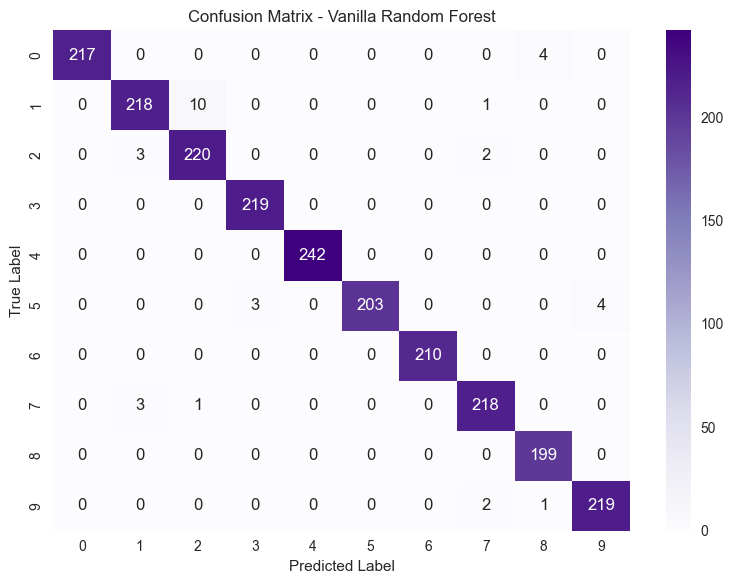

In [138]:
# Confusion matrix heatmap for test set
cm_rf = confusion_matrix(y_test, y_pred_test_rf)
cm_rf_df = pd.DataFrame(cm_rf, index=range(10), columns=range(10))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_df, annot=True, fmt="d", cmap="Purples")

plt.title("Confusion Matrix - Vanilla Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**Confusion matrix**: The confusion matrix shows that the Random Forest model correctly classifies the vast majority of handwritten digits, with only a small number of misclassifications. Compared with the Decision Tree model, the number of off-diagonal errors is lower, indicating stronger and more stable classification performance.

**Conclusion - RF Vanilla**:     
The diagonal values represent correctly classified observations.
Off-diagonal values indicate classification errors.
A strong concentration of values on the diagonal indicates high predictive performance.

### RF GridsearchCV

In [147]:
# To further optimize the Random Forest model, hyperparameter tuning was performed using GridSearchCV
# This process evaluates multiple parameter combinations through cross-validation and selects the configuration that provides the best validation performance

# The `criterion` parameter determines how split quality is measured
# The `max_depth` parameter limits tree depth and helps control complexity
# The `max_features` parameter controls how many features are considered at each split
# The `max_leaf_nodes` parameter limits the number of terminal nodes
# The `n_estimators` parameter controls the number of trees in the forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
rf_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [7, 8],
    "max_features": [0.8],
    "max_leaf_nodes": [180, 200],
    "n_estimators": [50, 100]
}

# Base model
rf_base = RandomForestClassifier(random_state=42)

# Grid search
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [7, 8], 'max_features': [0.8], 'max_leaf_nodes': [180, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [151]:
print("Best parameters:", rf_grid.best_params_)
print("Best cross-validation score:", round(rf_grid.best_score_, 4))

#The optimal Random Forest configuration selected by GridSearchCV was:
# criterion = entropy
# max_depth = 8
# max_features = 0.8
# max_leaf_nodes = 180
# n_estimators = 50
# These settings were selected to balance predictive accuracy and generalization performance.

Best parameters: {'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.8, 'max_leaf_nodes': 180, 'n_estimators': 50}
Best cross-validation score: 0.979


In [157]:
from sklearn.metrics import accuracy_score, f1_score

# Predictions
y_pred_test_rf_grid = rf_grid.predict(X_test)
y_pred_train_rf_grid = rf_grid.predict(X_train)

# Performance metrics
rf_grid_accuracy_test = accuracy_score(y_test, y_pred_test_rf_grid)
rf_grid_accuracy_train = accuracy_score(y_train, y_pred_train_rf_grid)

rf_grid_f1_test = f1_score(y_test, y_pred_test_rf_grid, average="macro")
rf_grid_f1_train = f1_score(y_train, y_pred_train_rf_grid, average="macro")

print("Tuned RF Test Accuracy:", round(rf_grid_accuracy_test, 4))
print("Tuned RF Train Accuracy:", round(rf_grid_accuracy_train, 4))
print("Tuned RF Test Macro F1:", round(rf_grid_f1_test, 4))
print("Tuned RF Train Macro F1:", round(rf_grid_f1_train, 4))


# The tuned Random Forest achieved approximately 97.68% accuracy on the test set and 99.35% accuracy on the training set 
# The macro F1-scores show a very similar pattern, indicating balanced predictive performance across classes
# Compared with the vanilla Random Forest model, the tuned version shows slightly lower test accuracy, 
# but the smaller gap between training and test results suggests improved control of overfitting

Tuned RF Test Accuracy: 0.9768
Tuned RF Train Accuracy: 0.9935
Tuned RF Test Macro F1: 0.9769
Tuned RF Train Macro F1: 0.9936


In [159]:
from sklearn.metrics import confusion_matrix, classification_report

print("TEST CONFUSION MATRIX\n", confusion_matrix(y_test, y_pred_test_rf_grid))
print("-" * 50)
print("TRAIN CONFUSION MATRIX\n", confusion_matrix(y_train, y_pred_train_rf_grid))

print("\nTEST CLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred_test_rf_grid, digits=3))

print("-" * 50)
print("TRAIN CLASSIFICATION REPORT\n")
print(classification_report(y_train, y_pred_train_rf_grid, digits=3))

TEST CONFUSION MATRIX
 [[217   0   0   0   0   0   0   0   4   0]
 [  0 215  13   0   0   0   0   1   0   0]
 [  0   2 220   0   0   0   0   3   0   0]
 [  0   1   0 217   0   1   0   0   0   0]
 [  0   1   0   0 240   0   0   0   0   1]
 [  0   0   0   5   0 200   0   0   1   4]
 [  0   0   0   0   0   0 210   0   0   0]
 [  0   4   1   1   0   0   0 215   1   0]
 [  1   0   0   0   0   0   0   0 198   0]
 [  0   1   0   2   0   0   0   2   1 216]]
--------------------------------------------------
TRAIN CONFUSION MATRIX
 [[921   0   0   0   0   0   0   0   0   1]
 [  0 884  16  14   0   0   0   0   0   0]
 [  0   2 914   2   0   0   0   1   0   0]
 [  0   2   2 828   0   1   0   2   0   1]
 [  0   0   0   0 900   0   0   0   0   2]
 [  0   0   0   2   0 843   0   0   0   0]
 [  0   0   0   0   0   0 846   0   0   0]
 [  0   1   1   3   0   0   0 915   0   0]
 [  0   0   0   0   0   0   0   0 856   0]
 [  0   1   0   2   1   0   0   0   0 829]]

TEST CLASSIFICATION REPORT

           

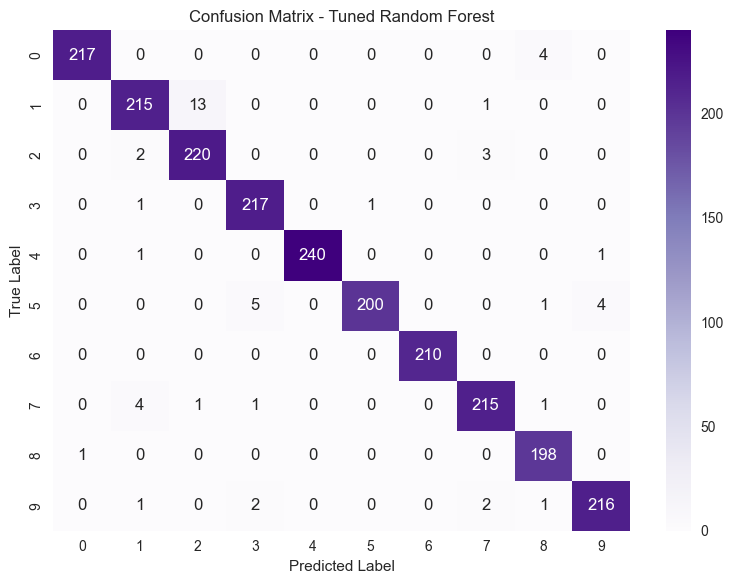

In [161]:
# Confusion matrix for tuned Random Forest
cm_rf_grid = confusion_matrix(y_test, y_pred_test_rf_grid)
cm_rf_grid_df = pd.DataFrame(cm_rf_grid, index=range(10), columns=range(10))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_grid_df, annot=True, fmt="d", cmap="Purples")

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**Confusion matrix**: The confusion matrix shows that the tuned Random Forest still performs strongly across nearly all digit classes, with most values concentrated on the diagonal. Although a small number of errors remain, the model maintains high predictive consistency across the multi-class classification task.

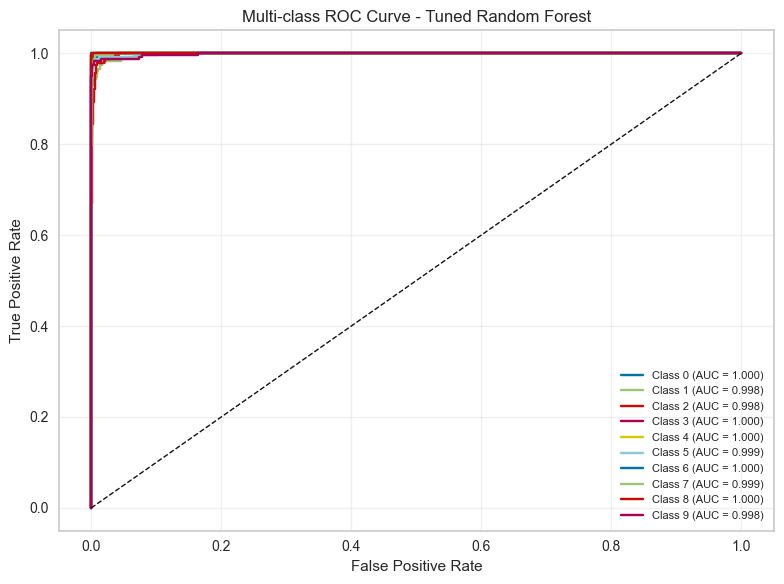

Macro-average ROC AUC: 0.9993


In [166]:
# Binarize the test labels
y_test_bin = label_binarize(y_test, classes=range(10))

# Predicted probabilities
y_pred_proba_rf = rf_grid.predict_proba(X_test)

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve - Tuned Random Forest")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Macro-average ROC-AUC
rf_roc_auc_macro = roc_auc_score(y_test_bin, y_pred_proba_rf, average="macro", multi_class="ovr")
print("Macro-average ROC AUC:", round(rf_roc_auc_macro, 4))


# The ROC-AUC analysis confirms that the tuned Random Forest retains strong class separability across the handwritten digit classes
# This indicates that the model remains highly effective in distinguishing between different categories, even after regularization

**Conclusion - RF GridsearchCV**:   
Hyperparameter tuning produced a more controlled Random Forest model with a smaller gap between training and test performance. Although the tuned model achieved slightly lower test accuracy than the vanilla Random Forest, it showed improved generalization control and remained highly effective overall. This suggests that the tuned Random Forest is a stable and reliable classifier, although the untuned version achieved the strongest raw predictive performance in this project.

# Compare The Models

## Accuracy Comparison

In [180]:
# SVM
svm_accuracy_test = accuracy_score(y_test, y_pred_test)
svm_f1_test = f1_score(y_test, y_pred_test, average="macro")

# Decision Tree
dt_accuracy_test = accuracy_score(y_test, y_pred_test_dt_grid)
dt_f1_test = f1_score(y_test, y_pred_test_dt_grid, average="macro")

# Random Forest
rf_accuracy_test = accuracy_score(y_test, y_pred_test_rf)
rf_f1_test = f1_score(y_test, y_pred_test_rf, average="macro")

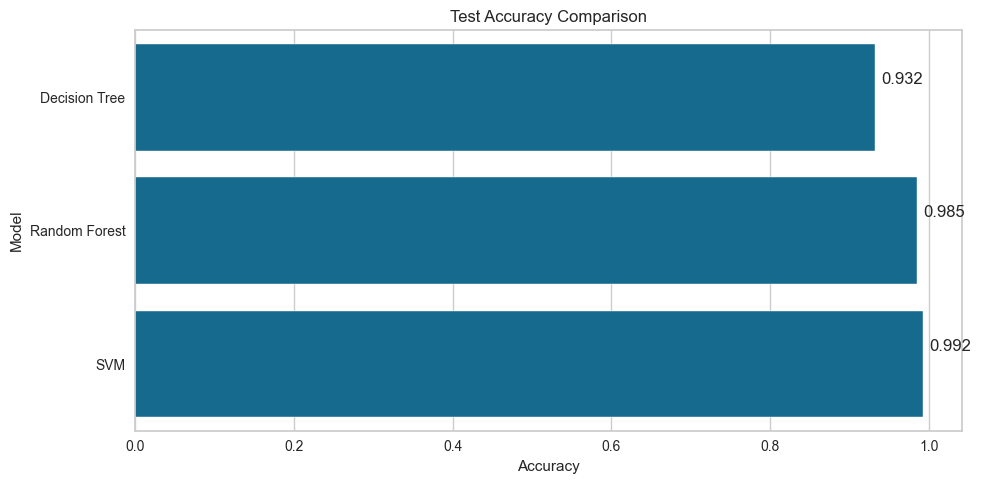

In [188]:
# Create comparison DataFrame
accuracy_df = pd.DataFrame({
    "Model": ["SVM", "Decision Tree", "Random Forest"],
    "Accuracy": [svm_accuracy_test, dt_accuracy_test, rf_accuracy_test]
})

# Sort values
accuracy_df = accuracy_df.sort_values(by="Accuracy", ascending=True)

# Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="Accuracy", y="Model", data=accuracy_df)

# Add labels
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}",
                (p.get_width(), p.get_y() + 0.3),
                xytext=(5, 0),
                textcoords="offset points")

plt.title("Test Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

**Accuracy comparison:**   
The accuracy comparison shows that SVM achieved the highest test accuracy (≈ 0.992), followed by Random Forest (≈ 0.985), while Decision Tree had the lowest performance (≈ 0.932). This indicates that SVM is the most accurate model for this task, while Random Forest also performs strongly. In contrast, Decision Tree demonstrates weaker generalization compared to the other models.

## F1 Score Comparison

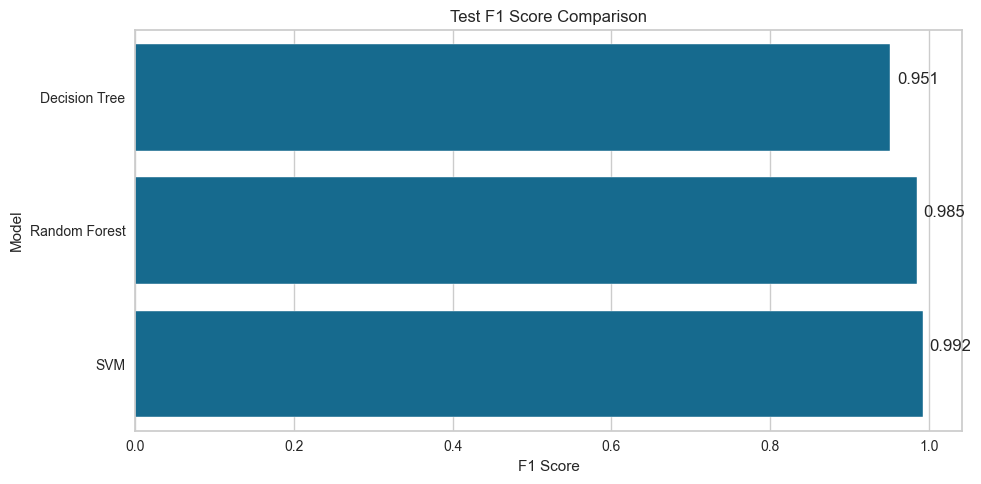

In [174]:
# Create comparison DataFrame
f1_df = pd.DataFrame({
    "Model": ["SVM", "Decision Tree", "Random Forest"],
    "F1 Score": [svm_f1_test, dt_f1_test, rf_f1_test]
})

# Sort values
f1_df = f1_df.sort_values(by="F1 Score", ascending=True)

# Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="F1 Score", y="Model", data=f1_df)

# Add labels
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}",
                (p.get_width(), p.get_y() + 0.3),
                xytext=(5, 0),
                textcoords="offset points")

plt.title("Test F1 Score Comparison")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

**F1-score comparison:**   
The F1-score comparison shows that **SVM achieved the highest performance (≈ 0.992)**, followed by Random Forest (≈ 0.985), while Decision Tree had the lowest score (≈ 0.951). This indicates that SVM provides the most balanced classification across all classes. Random Forest also demonstrates strong and consistent performance, whereas Decision Tree shows comparatively weaker class-level accuracy.

**Overall Comparison:**   
Based on both accuracy and F1-score, the **Support Vector Machine (SVM) is the best-performing model for this handwritten digit classification task**. Random Forest also demonstrates strong performance, achieving high accuracy and balanced predictions, but it does not surpass SVM. In contrast, the Decision Tree model shows the weakest results, mainly due to overfitting and lower generalization ability. Overall, the comparison highlights that more advanced models such as SVM and ensemble methods like Random Forest are better suited for complex, high-dimensional classification problems, while single Decision Trees are less effective in this context.

# Conclusion

**Overall Project Conclusion**:   
This project focused on the classification of handwritten digits using three machine learning models: Support Vector Machine (SVM), Decision Tree (DT), and Random Forest (RF).  
The results demonstrated that model choice has a significant impact on predictive performance and generalization ability. Among the evaluated models, SVM achieved the highest accuracy and F1-score, making it the most effective classifier for this task. Its ability to handle high-dimensional data and construct optimal decision boundaries allowed it to outperform the other models.   
Random Forest also showed strong performance, achieving high accuracy and balanced predictions across all classes. As an ensemble method, it successfully reduced overfitting compared to the Decision Tree and provided a robust alternative model.    
In contrast, the Decision Tree model showed the weakest performance. Although it is simple and interpretable, it suffered from overfitting in its baseline form and demonstrated lower generalization ability compared to the other models.   
Hyperparameter tuning improved the stability of both Decision Tree and Random Forest models by reducing overfitting. However, in some cases, this led to slightly lower test accuracy, highlighting the trade-off between model complexity and generalization.   
Overall, this project illustrates the importance of selecting appropriate models and tuning strategies for classification tasks. It also shows that advanced models such as SVM and ensemble methods are better suited for complex datasets like handwritten digits.


**Future Work**:    
Future improvements could include testing additional models such as Gradient Boosting or Neural Networks, performing more extensive hyperparameter optimization, and applying cross-validation strategies to further enhance model performance and reliability.

# <p style="background-color:green;font-family:newtimeroman;font-size:100%;color:white;text-align:center;border-radius:20px 20px;"><b>Faydalı Olması Temennisiyle Teşekkürler</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to hear about the latest updates, please don't forget to follow us! </b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [WhatsApp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [LinkedIn](https://www.linkedin.com/company/techproeducation/mycompany/) |